<a href="https://colab.research.google.com/github/fabriciothiengo/REATORES/blob/main/REGRESS%C3%83O_MEIA_VIDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DETERMINAÇÃO DE PARÂMETROS CINÉTICOS A PARTIR DO MÉTODO DE TEMPO DE MEIA VIDA**

O modelo de tempo de meia vida é o seguinte:

$$
ln\left(t_{1/2}\right) = ln\left[\frac{2^{n-1}-1}{k(n-1)}\right] + (1-n)ln\left(C_{a_0}\right)
$$

<br>
Os dados para o ajuste de regressão são:

$$
\begin{array}{c|c}
t_{1/2} & C_{A_0} \\
\hline
3.5 & 2 \\
5 & 1.5
\end{array}
$$

**OPÇÃO 1: UTILIZANDO A BIBLIOTECA SCIKIT-LEARN**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Dados
x = np.array([2, 1.5]).reshape(-1, 1)
x=np.log(x)
y = np.array([3.5, 5])
y=np.log(y)

# Modelo
modelo = LinearRegression()
modelo.fit(x, y)

# Previsão
y_pred = modelo.predict(x)

# Coeficientes
a = modelo.coef_[0]
ordem = 1-a

b = modelo.intercept_
k = (2**(ordem-1)-1)/((ordem-1)*np.exp(b))

# R²
r2 = modelo.score(x, y)

print(f"ordem: {ordem:.2f}")
print(f"k: {k:.2f}")
print(f"R²: {r2}")

ordem: 2.24
k: 0.13
R²: 1.0


A classe LinearRegression da biblioteca scikit-learn, após a execução do método `.fit(X, y)`, realiza internamente o ajuste de um modelo de regressão linear por mínimos quadrados ordinários (OLS) e passa a disponibilizar uma série de funcionalidades e informações derivadas desse ajuste.

Primeiramente, o modelo estima os coeficientes da regressão (`coef_`) e o intercepto (`intercept_`), resolvendo o problema de minimização do erro quadrático entre os valores observados e preditos. Essa solução é obtida de forma analítica, utilizando decomposição em valores singulares (SVD), o que garante maior estabilidade numérica, especialmente em casos de multicolinearidade ou quando a matriz de dados é mal condicionada.

Durante o processo de ajuste, caso o parâmetro `fit_intercept=True`, o algoritmo centraliza automaticamente os dados (subtrai a média das variáveis explicativas e da variável resposta), resolve o sistema sem intercepto e posteriormente reconstrói o termo independente. Esse procedimento melhora a precisão numérica da solução.

O modelo também é capaz de lidar com múltiplas variáveis explicativas (regressão múltipla) e múltiplas saídas simultaneamente (multi-output), resolvendo o sistema de forma vetorizada, o que aumenta a eficiência computacional.

Se pesos amostrais forem fornecidos (`sample_weight`), o modelo realiza um ajuste por mínimos quadrados ponderados, atribuindo diferentes importâncias às observações. Internamente, isso é feito por meio de uma transformação dos dados baseada na raiz quadrada dos pesos.

Após o ajuste, o modelo fornece informações adicionais sobre a estrutura do problema, como o posto da matriz de entrada (`rank_`) e seus valores singulares (`singular_`), que podem ser utilizados para diagnosticar problemas como dependência linear entre variáveis ou instabilidade numérica.

Além disso, o modelo armazena metadados como o número de variáveis explicativas (`n_features_in_`) e, quando disponível, os nomes das variáveis (`feature_names_in_`).

Com o modelo ajustado, é possível realizar predições através do método `.predict(X)`, que aplica diretamente a equação linear ajustada de forma vetorizada. Também é possível avaliar o desempenho do modelo utilizando o método `.score(X, y)`, que calcula automaticamente o coeficiente de determinação (R²).

A LinearRegression é totalmente compatível com o ecossistema do scikit-learn, podendo ser integrada em pipelines, validação cruzada e processos de otimização de hiperparâmetros.


**OPÇÃO 2: UTILIZANDO O POLYFIT DA BIBLIOTECA NUMPY**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dados de exemplo
x = np.array([2, 1.5])
x=np.log(x)
y = np.array([3.5, 5])
y=np.log(y)

# Ajuste linear (coeficientes)
a, b = np.polyfit(x, y, 1)

ordem=1-a
k = (2**(ordem-1)-1)/((ordem-1)*np.exp(b))

y_pred = a*x + b

# Cálculo do R²
ss_res = np.sum((y - y_pred)**2)        # soma dos resíduos
ss_tot = np.sum((y - np.mean(y))**2)    # soma total

r2 = 1 - (ss_res / ss_tot)

print(f"ordem: {ordem:.2f}")
print(f"k: {k:.2f}")
print(f"R² = {r2:.2f}")

ordem: 2.24
k: 0.13
R² = 1.00


**FAZENDO UM AJUSTE DE REGRESSÃO COM DADOS REAIS, ISTO É, QUE NÃO GERAM UM AJUSTE COM $R^2$ = 1**

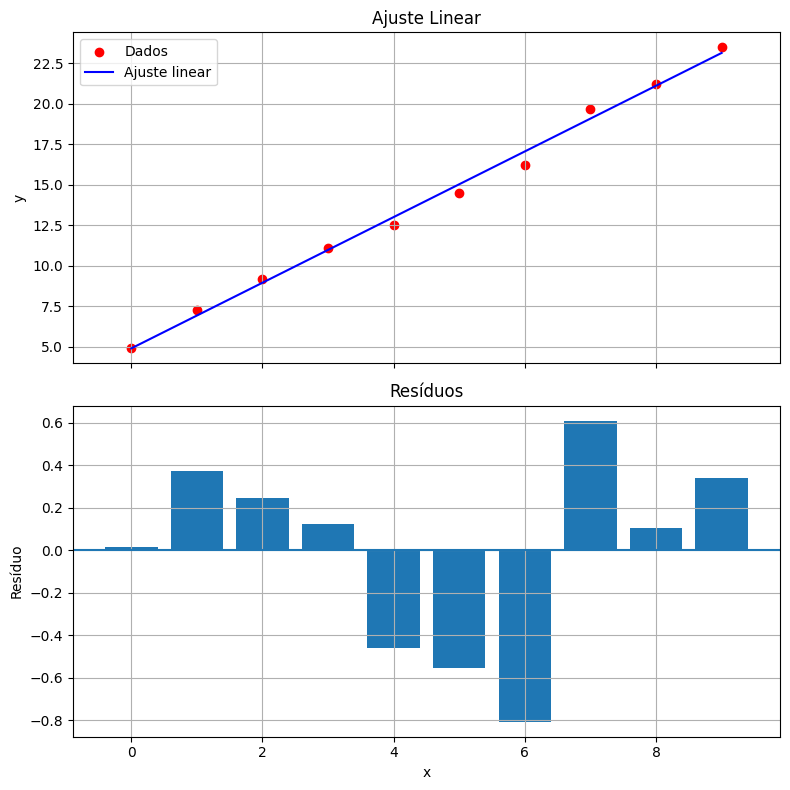

In [ ]:
x=np.array(np.linspace(0,9,10))
y=np.array([4.93,7.31,9.21,11.11,12.55,14.48,16.25,19.69,21.21,23.47])
a,b=np.polyfit(x,y,1)
y_pred=a*x+b
res=y-y_pred


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
#Gráfico 1: dados + ajuste
ax1.scatter(x, y, color='red', label='Dados')
ax1.plot(x, y_pred, color='blue', label='Ajuste linear')
ax1.set_ylabel('y')
ax1.set_title('Ajuste Linear')
ax1.legend()
ax1.grid()

#Gráfico 2: resíduos
ax2.bar(x, res)
ax2.axhline(0)  # linha no zero
ax2.set_xlabel('x')
ax2.set_ylabel('Resíduo')
ax2.set_title('Resíduos')
ax2.grid()

plt.tight_layout()
plt.show()


**Perceba que os resídos são tanto positivos quanto negativos, o que é o esperado. Há também uma visão clara de que os resíduos não são de mesma intensidade. Isso é um indicativo que o modelo pode não ser o mais adequado e/ou que em certas condições de x os equipamentos são menos precisos e/ou a condição experimental é mais suscetível a erro.**